In [1]:
#! Imports and source-only project setup
import hashlib
import json
import os
import random
import sys
import time

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision

from google.colab import drive
from IPython.display import display
from torchvision import models

drive.mount("/content/drive")

SEED = 6304
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False

ROOT = Path("/content/drive/MyDrive/pa1-beyond-iid")
PACS_DIR = ROOT / "data/pacs"
SHARED_DIR = ROOT / "shared"
TASK2_DIR = ROOT / "task2"
MODEL_DIR = TASK2_DIR / "models"
RESULT_DIR = TASK2_DIR / "results/source_only"
CONFIG_DIR = TASK2_DIR / "configs"
SPLIT_FILE = SHARED_DIR / "splits/pacs_sketch_seed6304.json"
BASE_PATH = CONFIG_DIR / "base.json"
INITIAL_PATH = MODEL_DIR / "resnet18_initial_seed6304.pt"
BEST_PATH = MODEL_DIR / "source_only_best.pt"
LAST_PATH = MODEL_DIR / "source_only_last.pt"
RUN_CONFIG_PATH = CONFIG_DIR / "source_only.json"

for folder in [MODEL_DIR, RESULT_DIR, CONFIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

#! Read ONLY source-side files and protocol configuration
source_files = [
    PACS_DIR / "pacs_sources.tar",
    PACS_DIR / "source_train.csv",
    PACS_DIR / "source_val.csv",
    SPLIT_FILE, BASE_PATH, SHARED_DIR / "pacs.py"
]

missing = [str(path) for path in source_files if not path.is_file()]

if missing:
    raise FileNotFoundError("Run Task 2A first; missing: " + str(missing))

with open(BASE_PATH) as file:
    base = json.load(file)

with open(SPLIT_FILE) as file:
    split_record = json.load(file)

SOURCE_DOMAINS = ["photo", "art_painting", "cartoon"]
LABEL_NAMES = base["class_names"]

if (base["seed"] != SEED or split_record["seed"] != SEED
        or base["source_domains"] != SOURCE_DOMAINS
        or len(LABEL_NAMES) != 7):
    raise ValueError("Task 2A protocol does not match Task 2B")

def file_sha256(path):
    digest = hashlib.sha256()

    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(4 * 1024 * 1024), b""):
            digest.update(chunk)

    return digest.hexdigest()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "— T4 GPU recommended")
print("Source domains:", SOURCE_DOMAINS)
print("Classes:", LABEL_NAMES)
print("Shared split:", SPLIT_FILE)

Mounted at /content/drive
Device: cuda — T4 GPU recommended
Source domains: ['photo', 'art_painting', 'cartoon']
Classes: ['dog', 'elephant', 'giraffe', 'guitar', 'horse', 'house', 'person']
Shared split: /content/drive/MyDrive/pa1-beyond-iid/shared/splits/pacs_sketch_seed6304.json


In [2]:
#! Load sources only; no target images or labels
sys.path.insert(0, str(SHARED_DIR))

from pacs import build_resnet18, make_loaders, set_seed, freeze_bn_running_stats

LOCAL_ROOT = Path("/content/pacs_source_only")

if (LOCAL_ROOT / "images/sketch").exists():
    raise RuntimeError("Source-only local folder unexpectedly contains Sketch")

source_loaders, val_loaders = make_loaders(
    PACS_DIR, LOCAL_ROOT, include_target=False, workers=2
)

train_manifest = pd.read_csv(PACS_DIR / "source_train.csv")
val_manifest = pd.read_csv(PACS_DIR / "source_val.csv")

if set(train_manifest["hf_index"]) & set(val_manifest["hf_index"]):
    raise ValueError("Train and validation images overlap")

for domain in SOURCE_DOMAINS:
    train_n = len(source_loaders[domain].dataset)
    val_n = len(val_loaders[domain].dataset)

    print(f"{domain}: train={train_n}, val={val_n}, train batches={len(source_loaders[domain])}")

    if not len(source_loaders[domain]):
        raise ValueError(f"No full training batches in {domain}")

STEPS_PER_EPOCH = max(len(loader) for loader in source_loaders.values())

print("Updates per source epoch:", STEPS_PER_EPOCH)
print("Total source batch size:", 8 * len(SOURCE_DOMAINS))
print("No Sketch images loaded.")

photo: train=1336, val=334, train batches=167
art_painting: train=1638, val=410, train batches=204
cartoon: train=1875, val=469, train batches=234
Updates per source epoch: 234
Total source batch size: 24
No Sketch images loaded.


In [3]:
#! Reproducible ImageNet ResNet-18 and shared classifier initialization
set_seed(SEED)

if INITIAL_PATH.is_file():
    initial = torch.load(INITIAL_PATH, map_location="cpu", weights_only=True)

    if initial["seed"] != SEED or initial["class_names"] != LABEL_NAMES:
        raise ValueError("Existing initialization is incompatible with the locked protocol")

    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 7)
    model.load_state_dict(initial["model_state_dict"], strict=True)

    print("Reusing locked initial checkpoint:", INITIAL_PATH)
else:
    model = build_resnet18(num_classes=7)

    initial = {
        "seed": SEED,
        "class_names": LABEL_NAMES,
        "pretrained": "ResNet18_Weights.IMAGENET1K_V1",
        "model_state_dict": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    }

    partial = INITIAL_PATH.with_name(INITIAL_PATH.name + ".partial")
    torch.save(initial, partial)
    os.replace(partial, INITIAL_PATH)

    print("Saved shared initialization:", INITIAL_PATH)

INITIAL_SHA = file_sha256(INITIAL_PATH)
BN_REFERENCE = {name: value.detach().cpu().clone()
                for name, value in initial["model_state_dict"].items()
                if name.endswith(("running_mean", "running_var", "num_batches_tracked"))}

model = model.to(DEVICE)

print("Initial checkpoint SHA-256:", INITIAL_SHA)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("BatchNorm affine trainable:", all(
    layer.weight.requires_grad and layer.bias.requires_grad
    for layer in model.modules() if isinstance(layer, nn.modules.batchnorm._BatchNorm)
))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


Saved shared initialization: /content/drive/MyDrive/pa1-beyond-iid/task2/models/resnet18_initial_seed6304.pt
Initial checkpoint SHA-256: b7a7953b493b6a3b5e6ae577ed139bc7f99da62686a5a4af523fd72def8a5e07
Trainable parameters: 11180103
BatchNorm affine trainable: True


In [4]:
#! Write reusable training code for the next methods
TRAINING_MODULE = '#! Shared source-side training utilities for PACS Tasks 2 and 3\nimport os\nfrom contextlib import nullcontext\nfrom pathlib import Path\n\nimport numpy as np\nimport torch\nimport torch.nn.functional as F\nfrom sklearn.metrics import accuracy_score, f1_score\n\nfrom pacs import SOURCE_DOMAINS, freeze_bn_running_stats\n\n\ndef set_epoch_loaders(source_loaders, epoch, seed=6304):\n    #! Reset source-shuffle/augmentation seeds at the start of every epoch.\n    for index, domain in enumerate(SOURCE_DOMAINS):\n        source_loaders[domain].generator.manual_seed(seed + epoch * 1000 + index)\n\n\ndef train_source_epoch(model, source_loaders, optimizer, device, epoch, scaler=None, seed=6304):\n    #! A source epoch spans the longest domain loader; cycle shorter domains.\n    model.train()\n    freeze_bn_running_stats(model)\n    set_epoch_loaders(source_loaders, epoch, seed)\n    iterators = {domain: iter(source_loaders[domain]) for domain in SOURCE_DOMAINS}\n    steps = max(len(source_loaders[domain]) for domain in SOURCE_DOMAINS)\n    if not steps:\n        raise ValueError("A source loader contains no full batches")\n\n    total_loss, total_correct, total_seen = 0.0, 0, 0\n    domain_correct = {domain: 0 for domain in SOURCE_DOMAINS}\n    domain_seen = {domain: 0 for domain in SOURCE_DOMAINS}\n    amp_enabled = device.type == "cuda" and scaler is not None and scaler.is_enabled()\n\n    for _ in range(steps):\n        batches = []\n        for domain in SOURCE_DOMAINS:\n            try:\n                batch = next(iterators[domain])\n            except StopIteration:\n                iterators[domain] = iter(source_loaders[domain])\n                batch = next(iterators[domain])\n            batches.append(batch)\n\n        images = torch.cat([batch[0] for batch in batches], dim=0).to(device, non_blocking=True)\n        labels = torch.cat([batch[1] for batch in batches], dim=0).to(device, non_blocking=True)\n        optimizer.zero_grad(set_to_none=True)\n\n        context = torch.autocast(device_type="cuda", dtype=torch.float16) if amp_enabled else nullcontext()\n        with context:\n            logits = model(images)\n            loss = F.cross_entropy(logits, labels)\n\n        if amp_enabled:\n            scaler.scale(loss).backward()\n            scaler.step(optimizer)\n            scaler.update()\n        else:\n            loss.backward()\n            optimizer.step()\n\n        predictions = logits.detach().argmax(dim=1)\n        n = len(labels)\n        total_loss += float(loss.detach()) * n\n        total_correct += int((predictions == labels).sum().item())\n        total_seen += n\n        offset = 0\n        for domain, (domain_images, _) in zip(SOURCE_DOMAINS, batches):\n            count = len(domain_images)\n            domain_correct[domain] += int((predictions[offset:offset + count] == labels[offset:offset + count]).sum().item())\n            domain_seen[domain] += count\n            offset += count\n\n    result = {\n        "train_loss": total_loss / total_seen,\n        "train_accuracy": total_correct / total_seen,\n        "updates": steps,\n        "source_examples_processed": total_seen,\n    }\n    result.update({f"train_{domain}_accuracy": domain_correct[domain] / domain_seen[domain]\n                   for domain in SOURCE_DOMAINS})\n    return result\n\n\n@torch.inference_mode()\ndef evaluate_sources(model, validation_loaders, device, num_classes=7):\n    #! All three source validation sets; never access Sketch here.\n    model.eval()\n    results = {}\n    for domain in SOURCE_DOMAINS:\n        total_loss, total_seen = 0.0, 0\n        targets, predictions = [], []\n        for images, labels in validation_loaders[domain]:\n            images = images.to(device, non_blocking=True)\n            labels = labels.to(device, non_blocking=True)\n            logits = model(images)\n            total_loss += F.cross_entropy(logits, labels, reduction="sum").item()\n            total_seen += len(labels)\n            targets.extend(labels.cpu().tolist())\n            predictions.extend(logits.argmax(dim=1).cpu().tolist())\n        if not total_seen:\n            raise ValueError(f"Validation domain {domain} is empty")\n        results[domain] = {\n            "accuracy": float(accuracy_score(targets, predictions)),\n            "macro_f1": float(f1_score(targets, predictions, labels=list(range(num_classes)),\n                                       average="macro", zero_division=0)),\n            "loss": total_loss / total_seen,\n            "n_images": total_seen,\n        }\n\n    results["mean_accuracy"] = float(np.mean([results[d]["accuracy"] for d in SOURCE_DOMAINS]))\n    results["mean_macro_f1"] = float(np.mean([results[d]["macro_f1"] for d in SOURCE_DOMAINS]))\n    results["worst_source_accuracy"] = float(min(results[d]["accuracy"] for d in SOURCE_DOMAINS))\n    results["worst_source_macro_f1"] = float(min(results[d]["macro_f1"] for d in SOURCE_DOMAINS))\n    return results\n\n\ndef atomic_torch_save(payload, destination):\n    #! Prevent an interrupted Drive write from destroying a valid checkpoint.\n    destination = Path(destination)\n    destination.parent.mkdir(parents=True, exist_ok=True)\n    partial = destination.with_name(destination.name + ".partial")\n    torch.save(payload, partial)\n    os.replace(partial, destination)\n\n\ndef cpu_state_dict(model):\n    return {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}\n'

TRAINING_PATH = SHARED_DIR / "pacs_training.py"

if TRAINING_PATH.exists():
    if TRAINING_PATH.read_text(encoding="utf-8") != TRAINING_MODULE:
        raise RuntimeError("Existing shared training module differs; do not silently overwrite it")
    print("Reusing shared training module:", TRAINING_PATH)
else:
    TRAINING_PATH.write_text(TRAINING_MODULE, encoding="utf-8")
    print("Saved shared training module:", TRAINING_PATH)

from pacs_training import (
    train_source_epoch, evaluate_sources, atomic_torch_save, cpu_state_dict
)
print("Shared training functions imported.")

Saved shared training module: /content/drive/MyDrive/pa1-beyond-iid/shared/pacs_training.py
Shared training functions imported.


In [5]:
#! Lock this experiment; preserve checkpoints and stop criteria
RUN_CONFIG = {
    "method": "source_only_erm",
    "seed": SEED,
    "base_config_sha256": file_sha256(BASE_PATH),
    "source_split_sha256": file_sha256(SPLIT_FILE),
    "source_train_manifest_sha256": file_sha256(PACS_DIR / "source_train.csv"),
    "source_val_manifest_sha256": file_sha256(PACS_DIR / "source_val.csv"),
    "initial_checkpoint_sha256": INITIAL_SHA,
    "source_domains": SOURCE_DOMAINS,
    "training_batch_per_domain": 8,
    "steps_per_source_epoch": STEPS_PER_EPOCH,
    "epoch_definition": "longest source loader once; cycle shorter source loaders",
    "optimizer": "AdamW",
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "max_epochs": 30,
    "patience": 5,
    "checkpoint_metric": "unweighted_mean_source_validation_macro_f1",
    "batchnorm": "running statistics frozen; affine parameters trained",
    "target_data_used": False,
}

if RUN_CONFIG_PATH.exists():
    with open(RUN_CONFIG_PATH) as file:
        if json.load(file) != RUN_CONFIG:
            raise RuntimeError("Existing source-only run configuration differs")
else:
    with open(RUN_CONFIG_PATH, "w") as file:
        json.dump(RUN_CONFIG, file, indent=2)

RUN_SHA = file_sha256(RUN_CONFIG_PATH)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")

history = []
best_f1, best_epoch, bad_epochs, start_epoch = -1.0, 0, 0, 1
training_finished = False

if LAST_PATH.is_file():
    last = torch.load(LAST_PATH, map_location="cpu", weights_only=True)

    if last["run_config_sha256"] != RUN_SHA:
        raise RuntimeError("Saved training state belongs to another configuration")

    model.load_state_dict(last["model_state_dict"], strict=True)
    optimizer.load_state_dict(last["optimizer_state_dict"])
    scaler.load_state_dict(last["scaler_state_dict"])
    history = last["history"]
    best_f1, best_epoch = last["best_f1"], last["best_epoch"]
    bad_epochs = last["bad_epochs"]
    start_epoch = last["epoch"] + 1
    training_finished = last["finished"]

    if not BEST_PATH.is_file():
        raise FileNotFoundError("Best checkpoint missing although resumable state exists")

    print("Restored epoch:", last["epoch"], "finished:", training_finished)
else:
    if BEST_PATH.is_file():
        raise RuntimeError("Best model exists without resume state. Preserve it; investigate first.")
    print("Starting from shared initial weights.")

print("Best epoch:", best_epoch, "next epoch:", start_epoch)
print("Source-only run locked:", RUN_CONFIG_PATH)

Starting from shared initial weights.
Best epoch: 0 next epoch: 1
Source-only run locked: /content/drive/MyDrive/pa1-beyond-iid/task2/configs/source_only.json


In [6]:
#! Source-only ERM training; source-validation checkpoint selection
if training_finished:
    print("Training already complete — no rerun or checkpoint overwrite.")
else:
    for epoch in range(start_epoch, RUN_CONFIG["max_epochs"] + 1):
        start_time = time.perf_counter()

        train_metrics = train_source_epoch(
            model, source_loaders, optimizer, DEVICE, epoch, scaler=scaler, seed=SEED
        )

        val_metrics = evaluate_sources(model, val_loaders, DEVICE, num_classes=7)
        score = val_metrics["mean_macro_f1"]

        improved = score > best_f1 + 1e-8

        if improved:
            best_f1, best_epoch, bad_epochs = score, epoch, 0
            atomic_torch_save({
                "method": "source_only_erm",
                "seed": SEED,
                "epoch": epoch,
                "best_source_val_mean_macro_f1": best_f1,
                "source_validation": val_metrics,
                "run_config_sha256": RUN_SHA,
                "initial_checkpoint_sha256": INITIAL_SHA,
                "class_names": LABEL_NAMES,
                "model_state_dict": cpu_state_dict(model),
            }, BEST_PATH)
        else:
            bad_epochs += 1

        row = {"epoch": epoch, **train_metrics,
               "mean_source_val_accuracy": val_metrics["mean_accuracy"],
               "mean_source_val_macro_f1": val_metrics["mean_macro_f1"],
               "worst_source_val_macro_f1": val_metrics["worst_source_macro_f1"],
               "elapsed_seconds": time.perf_counter() - start_time}

        for domain in SOURCE_DOMAINS:
            row[f"val_{domain}_accuracy"] = val_metrics[domain]["accuracy"]
            row[f"val_{domain}_macro_f1"] = val_metrics[domain]["macro_f1"]
            row[f"val_{domain}_loss"] = val_metrics[domain]["loss"]

        history.append(row)

        training_finished = bad_epochs >= RUN_CONFIG["patience"] or epoch == RUN_CONFIG["max_epochs"]

        atomic_torch_save({
            "epoch": epoch,
            "finished": training_finished,
            "model_state_dict": cpu_state_dict(model),
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "history": history,
            "best_epoch": best_epoch,
            "best_f1": best_f1,
            "bad_epochs": bad_epochs,
            "run_config_sha256": RUN_SHA,
        }, LAST_PATH)

        pd.DataFrame(history).to_csv(RESULT_DIR / "history.csv", index=False)

        print(f"Epoch {epoch:02d} | train CE {row['train_loss']:.4f} | "
              f"mean source val macro-F1 {score:.4f} | best {best_f1:.4f} "
              f"(epoch {best_epoch}) | no-improvement {bad_epochs}/5 | "
              f"{row['elapsed_seconds']:.1f}s")

        if training_finished:
            break

print("Training finished:", training_finished)
print("Best source-validation epoch:", best_epoch)
print("Best mean source-validation macro-F1:", round(best_f1, 5))

Epoch 01 | train CE 0.4599 | mean source val macro-F1 0.9231 | best 0.9231 (epoch 1) | no-improvement 0/5 | 30.6s
Epoch 02 | train CE 0.2101 | mean source val macro-F1 0.9237 | best 0.9237 (epoch 2) | no-improvement 0/5 | 29.3s
Epoch 03 | train CE 0.1293 | mean source val macro-F1 0.9268 | best 0.9268 (epoch 3) | no-improvement 0/5 | 30.8s
Epoch 04 | train CE 0.1104 | mean source val macro-F1 0.9001 | best 0.9268 (epoch 3) | no-improvement 1/5 | 32.0s
Epoch 05 | train CE 0.1210 | mean source val macro-F1 0.9371 | best 0.9371 (epoch 5) | no-improvement 0/5 | 30.9s
Epoch 06 | train CE 0.0890 | mean source val macro-F1 0.9181 | best 0.9371 (epoch 5) | no-improvement 1/5 | 30.9s
Epoch 07 | train CE 0.0673 | mean source val macro-F1 0.9275 | best 0.9371 (epoch 5) | no-improvement 2/5 | 30.0s
Epoch 08 | train CE 0.0884 | mean source val macro-F1 0.9150 | best 0.9371 (epoch 5) | no-improvement 3/5 | 29.8s
Epoch 09 | train CE 0.0484 | mean source val macro-F1 0.9462 | best 0.9462 (epoch 9) | n

In [7]:
#! Report-ready source-validation metrics from the BEST checkpoint

if not training_finished or not BEST_PATH.is_file():
    raise RuntimeError("Finish source-only training before evaluating")

best = torch.load(BEST_PATH, map_location="cpu", weights_only=True)

if best["run_config_sha256"] != RUN_SHA:
    raise ValueError("Best checkpoint does not match the run config")

model.load_state_dict(best["model_state_dict"], strict=True)
source_validation = evaluate_sources(model, val_loaders, DEVICE, num_classes=7)

rows = [{"domain": domain, **source_validation[domain]} for domain in SOURCE_DOMAINS]

rows.append({"domain": "mean", "accuracy": source_validation["mean_accuracy"],
             "macro_f1": source_validation["mean_macro_f1"], "loss": None, "n_images": None})
rows.append({"domain": "worst", "accuracy": source_validation["worst_source_accuracy"],
             "macro_f1": source_validation["worst_source_macro_f1"], "loss": None, "n_images": None})

val_df = pd.DataFrame(rows)
val_df.to_csv(RESULT_DIR / "source_validation.csv", index=False)

summary = {
    "method": "source_only_erm", "seed": SEED, "best_epoch": best["epoch"],
    "best_source_val_mean_macro_f1": best["best_source_val_mean_macro_f1"],
    "source_validation": source_validation,
    "checkpoint_path": str(BEST_PATH), "initial_checkpoint_path": str(INITIAL_PATH),
    "source_train_images": len(train_manifest), "source_validation_images": len(val_manifest),
    "target_data_or_labels_used": False,
    "target_performance": "NOT_EVALUATED_yet"
}

with open(RESULT_DIR / "summary.json", "w") as file:
    json.dump(summary, file, indent=2)

print("Best checkpoint:", BEST_PATH)
print("Source-only results (no Sketch):")
display(val_df.round(4))

Best checkpoint: /content/drive/MyDrive/pa1-beyond-iid/task2/models/source_only_best.pt
Source-only results (no Sketch):


,domain,accuracy,macro_f1,loss,n_images
0,photo,0.9760,0.9726,0.0606,334.0
1,art_painting,0.9122,0.9136,0.3011,410.0
2,cartoon,0.9488,0.9524,0.2133,469.0
3,mean,0.9457,0.9462,NaN,NaN
4,worst,0.9122,0.9136,NaN,NaN


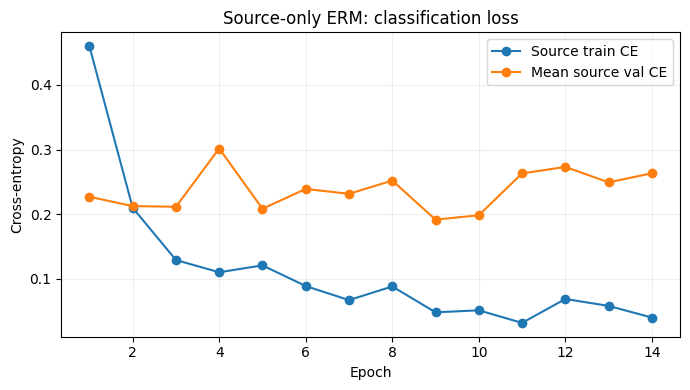

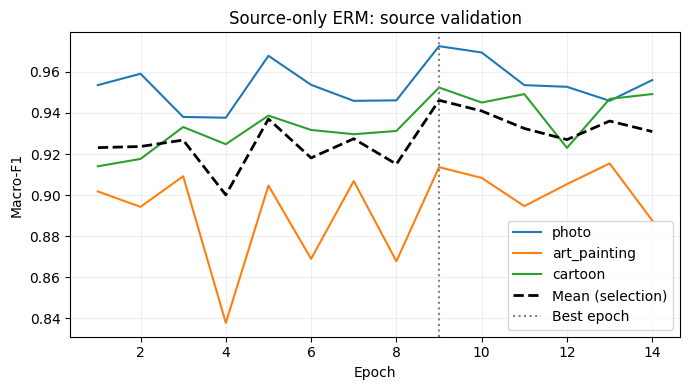

Frozen BatchNorm policy verified. Checked buffers: 60


In [8]:
#! Plot reusable evidence and check frozen BN running statistics
history_df = pd.read_csv(RESULT_DIR / "history.csv")

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Source train CE")
ax.plot(history_df["epoch"], history_df[[f"val_{d}_loss" for d in SOURCE_DOMAINS]].mean(axis=1),
        marker="o", label="Mean source val CE")
ax.set(xlabel="Epoch", ylabel="Cross-entropy", title="Source-only ERM: classification loss")
ax.grid(alpha=0.2)
ax.legend()

fig.tight_layout()
fig.savefig(RESULT_DIR / "classification_loss.png", dpi=250)

plt.show()

fig, ax = plt.subplots(figsize=(7, 4))

for domain in SOURCE_DOMAINS:
    ax.plot(history_df["epoch"], history_df[f"val_{domain}_macro_f1"], label=domain)

ax.plot(history_df["epoch"], history_df["mean_source_val_macro_f1"],
        color="black", linewidth=2, linestyle="--", label="Mean (selection)")
ax.axvline(best_epoch, color="grey", linestyle=":", label="Best epoch")
ax.set(xlabel="Epoch", ylabel="Macro-F1", title="Source-only ERM: source validation")
ax.grid(alpha=0.2)
ax.legend()

fig.tight_layout()
fig.savefig(RESULT_DIR / "source_macro_f1.png", dpi=250)

plt.show()

#! BN buffers must equal pretrained initialization at selected checkpoint
current_state = model.state_dict()
bn_mismatches = [name for name, value in BN_REFERENCE.items()
                 if not torch.equal(current_state[name].detach().cpu(), value)]
if bn_mismatches:
    raise RuntimeError("BatchNorm running statistics changed: " + str(bn_mismatches[:5]))

if not all(layer.weight.requires_grad and layer.bias.requires_grad
           for layer in model.modules() if isinstance(layer, nn.modules.batchnorm._BatchNorm)):
    raise RuntimeError("BatchNorm affine parameters must remain trainable")

with open(RESULT_DIR / "batchnorm_audit.json", "w") as file:
    json.dump({"running_stats_identical_to_initial": True,
               "checked_buffers": len(BN_REFERENCE), "bn_affine_trainable": True}, file, indent=2)

print("Frozen BatchNorm policy verified. Checked buffers:", len(BN_REFERENCE))

In [9]:
#! Verify permanent source-only artifacts on Google Drive

required = [INITIAL_PATH, BEST_PATH, LAST_PATH, RUN_CONFIG_PATH,
            SHARED_DIR / "pacs_training.py", RESULT_DIR / "history.csv",
            RESULT_DIR / "source_validation.csv", RESULT_DIR / "summary.json",
            RESULT_DIR / "batchnorm_audit.json", RESULT_DIR / "classification_loss.png",
            RESULT_DIR / "source_macro_f1.png"]

missing = [str(path) for path in required if not path.is_file()]

if missing:
    raise FileNotFoundError("Missing saved outputs: " + str(missing))

saved_best = torch.load(BEST_PATH, map_location="cpu", weights_only=True)
saved_last = torch.load(LAST_PATH, map_location="cpu", weights_only=True)
saved_val = pd.read_csv(RESULT_DIR / "source_validation.csv")
saved_history = pd.read_csv(RESULT_DIR / "history.csv")

if not saved_last["finished"] or saved_best["epoch"] != best_epoch:
    raise ValueError("Training state or best checkpoint is incomplete")

if not np.isclose(saved_val.loc[saved_val.domain == "mean", "macro_f1"].iloc[0],
                  saved_best["best_source_val_mean_macro_f1"], atol=1e-8):
    raise ValueError("Saved source metrics disagree with checkpoint")

if len(saved_history) != saved_last["epoch"]:
    raise ValueError("Training history is incomplete")

print("TASK 2B COMPLETE — SOURCE-ONLY ERM")
print("Files checked:", len(required))
print("Best epoch:", saved_best["epoch"])
print("Best mean source macro-F1:", round(saved_best["best_source_val_mean_macro_f1"], 4))
print("Reusable Task 3 checkpoint:", BEST_PATH)
print("Sketch evaluation: deferred until all Task 2 methods are locked.")

TASK 2B COMPLETE — SOURCE-ONLY ERM
Files checked: 11
Best epoch: 9
Best mean source macro-F1: 0.9462
Reusable Task 3 checkpoint: /content/drive/MyDrive/pa1-beyond-iid/task2/models/source_only_best.pt
Sketch evaluation: deferred until all Task 2 methods are locked.
